#Install Dependencies

_(Remember to choose GPU in Runtime if not already selected. Runtime --> Change Runtime Type --> Hardware accelerator --> GPU)_

In [ ]:
!nvidia-smi


Fri Apr  3 20:40:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
  # install dependencies (ignore errors)
import torch

from IPython.display import Image, clear_output  # to display images
# from utils.google_utils import gdrive_download  # to download models/datasets

# clear_output()
print('Setup complete. Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))

Setup complete. Using torch 2.10.0+cpu CPU


# Your Custom Data

In [ ]:
pwd

'/content'

In [ ]:
!rm -rf /content/runs

In [ ]:
%cd /content

/content


In [ ]:
import gdown

url = "https://drive.google.com/file/d/1ECfl3dtYyfivY8kYPq7RHUBTjC-2vf61/view?usp=share_link"

file_id = url.split("/")[-2]
print(file_id)
prefix = 'https://drive.google.com/uc?/export=download&id='
gdown.download(prefix+file_id)
print("Data downloaded!")

1ECfl3dtYyfivY8kYPq7RHUBTjC-2vf61


Downloading...
From (original): https://drive.google.com/uc?/export=download&id=1ECfl3dtYyfivY8kYPq7RHUBTjC-2vf61
From (redirected): https://drive.google.com/uc?%2Fexport=download&id=1ECfl3dtYyfivY8kYPq7RHUBTjC-2vf61&confirm=t&uuid=3a62bd44-7761-43b5-a277-7a697f81fc3b
To: /content/waste-detection.zip
100%|██████████| 40.1M/40.1M [00:01<00:00, 28.3MB/s]

Data downloaded!


In [ ]:
!unzip waste-detection.zip
!rm -rf waste-detection.zip

Archive:  waste-detection.zip
  inflating: data.yaml               
   creating: train/
   creating: train/images/
  inflating: train/images/Banana_10_jpg.rf.7c0536bc9eb72ec77c8f515653f44fb9.jpg  
  inflating: train/images/Banana_11_jpg.rf.188551ec3d51326e5562675d285d0e6a.jpg  
  inflating: train/images/Banana_12_jpg.rf.2ecabc9628a9611963e4804d13045377.jpg  
  inflating: train/images/Banana_12_jpg.rf.e951f9b4b66c9896ce6b7a56f9d41438.jpg  
  inflating: train/images/Banana_15_jpg.rf.09c5d34e95e0c06a808a99533e8e737c.jpg  
  inflating: train/images/Banana_15_jpg.rf.c2909c26fa3140f1734b451bead6752b.jpg  
  inflating: train/images/Banana_15_jpg.rf.e7fb3723604fb753bdbca26f382d7aaf.jpg  
  inflating: train/images/Banana_16_jpg.rf.504aa1c1679f9d595e336eba25f6d80c.jpg  
  inflating: train/images/Banana_16_jpg.rf.73833169c2979508c979f27bcb572959.jpg  
  inflating: train/images/Banana_16_jpg.rf.bd09b3cf6ae33d668a421a48b8c4b34b.jpg  
  inflating: train/images/Banana_16_jpg.rf.dbfad378a52e84709bbb24

In [ ]:
# this is the YAML file  we're loading into this notebook with our data
%cat data.yaml

train: ../train/images
val: ../valid/images


nc: 13
names: ['banana', 'chilli', 'drinkcan', 'drinkpack', 'foodcan', 'lettuce', 'paperbag', 'plasticbag', 'plasticbottle', 'plasticcontainer', 'sweetpotato', 'teabag', 'tissueroll']



# Define Model Configuration and Architecture

We will write a yaml script that defines the parameters for our model like the number of classes, anchors, and each layer.

You do not need to edit these cells, but you may.

In [ ]:
# define number of classes based on YAML
import yaml
with open("data.yaml", 'r') as stream:
    num_classes = str(yaml.safe_load(stream)['nc'])

In [ ]:
num_classes

'13'

# Train Custom YOLO26 Detector

### Next, we'll fire off training!


Here, we are able to pass a number of arguments:
- **img:** define input image size
- **batch:** determine batch size
- **epochs:** define the number of training epochs. (Note: often, 3000+ are common here!)
- **data:** set the path to our yaml file
- **cfg:** specify our model configuration
- **weights:** specify a custom path to weights. (Note: you can download weights from the Ultralytics Google Drive [folder](https://drive.google.com/open?id=1Drs_Aiu7xx6S-ix95f9kNsA6ueKRpN2J))
- **name:** result names
- **nosave:** only save the final checkpoint
- **cache:** cache images for faster training

In [ ]:
# Install the Ultralytics package (includes YOLO26)
!pip install -U ultralytics

# Verify the installation
import ultralytics
ultralytics.checks()

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


## YOLO-26 

This code uses the Ultralytics YOLO library to load a pretrained YOLO model (`yolo26s.pt`) for object detection.
It initializes the model and trains it on a custom dataset defined in `data.yaml`, which contains paths and class labels.
The training runs for 100 epochs, allowing the model to iteratively improve its detection accuracy.
Results, including weights and logs, are saved to a specified Google Drive directory for persistence.
The run is labeled `waste_run_1`, helping distinguish this experiment from others in the same project.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

model.train(
    data=r"/content/data.yaml",
    epochs=100,
    project="/content/drive/MyDrive/YOLO26_WasteProject", # Saves to your Drive!
    name="waste_run_1"
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=waste_run_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d86edd232c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

# Evaluate Custom YOLO26 Detector Performance

Training losses and performance metrics are saved to Tensorboard and also to a logfile defined above with the **--name** flag when we train. In our case, we named this `yolov26_results`. (If given no name, it defaults to `results.txt`.) The results file is plotted as a png after training completes.

Note from Glenn: Partially completed `results.txt` files can be plotted with `from utils.utils import plot_results; plot_results()`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


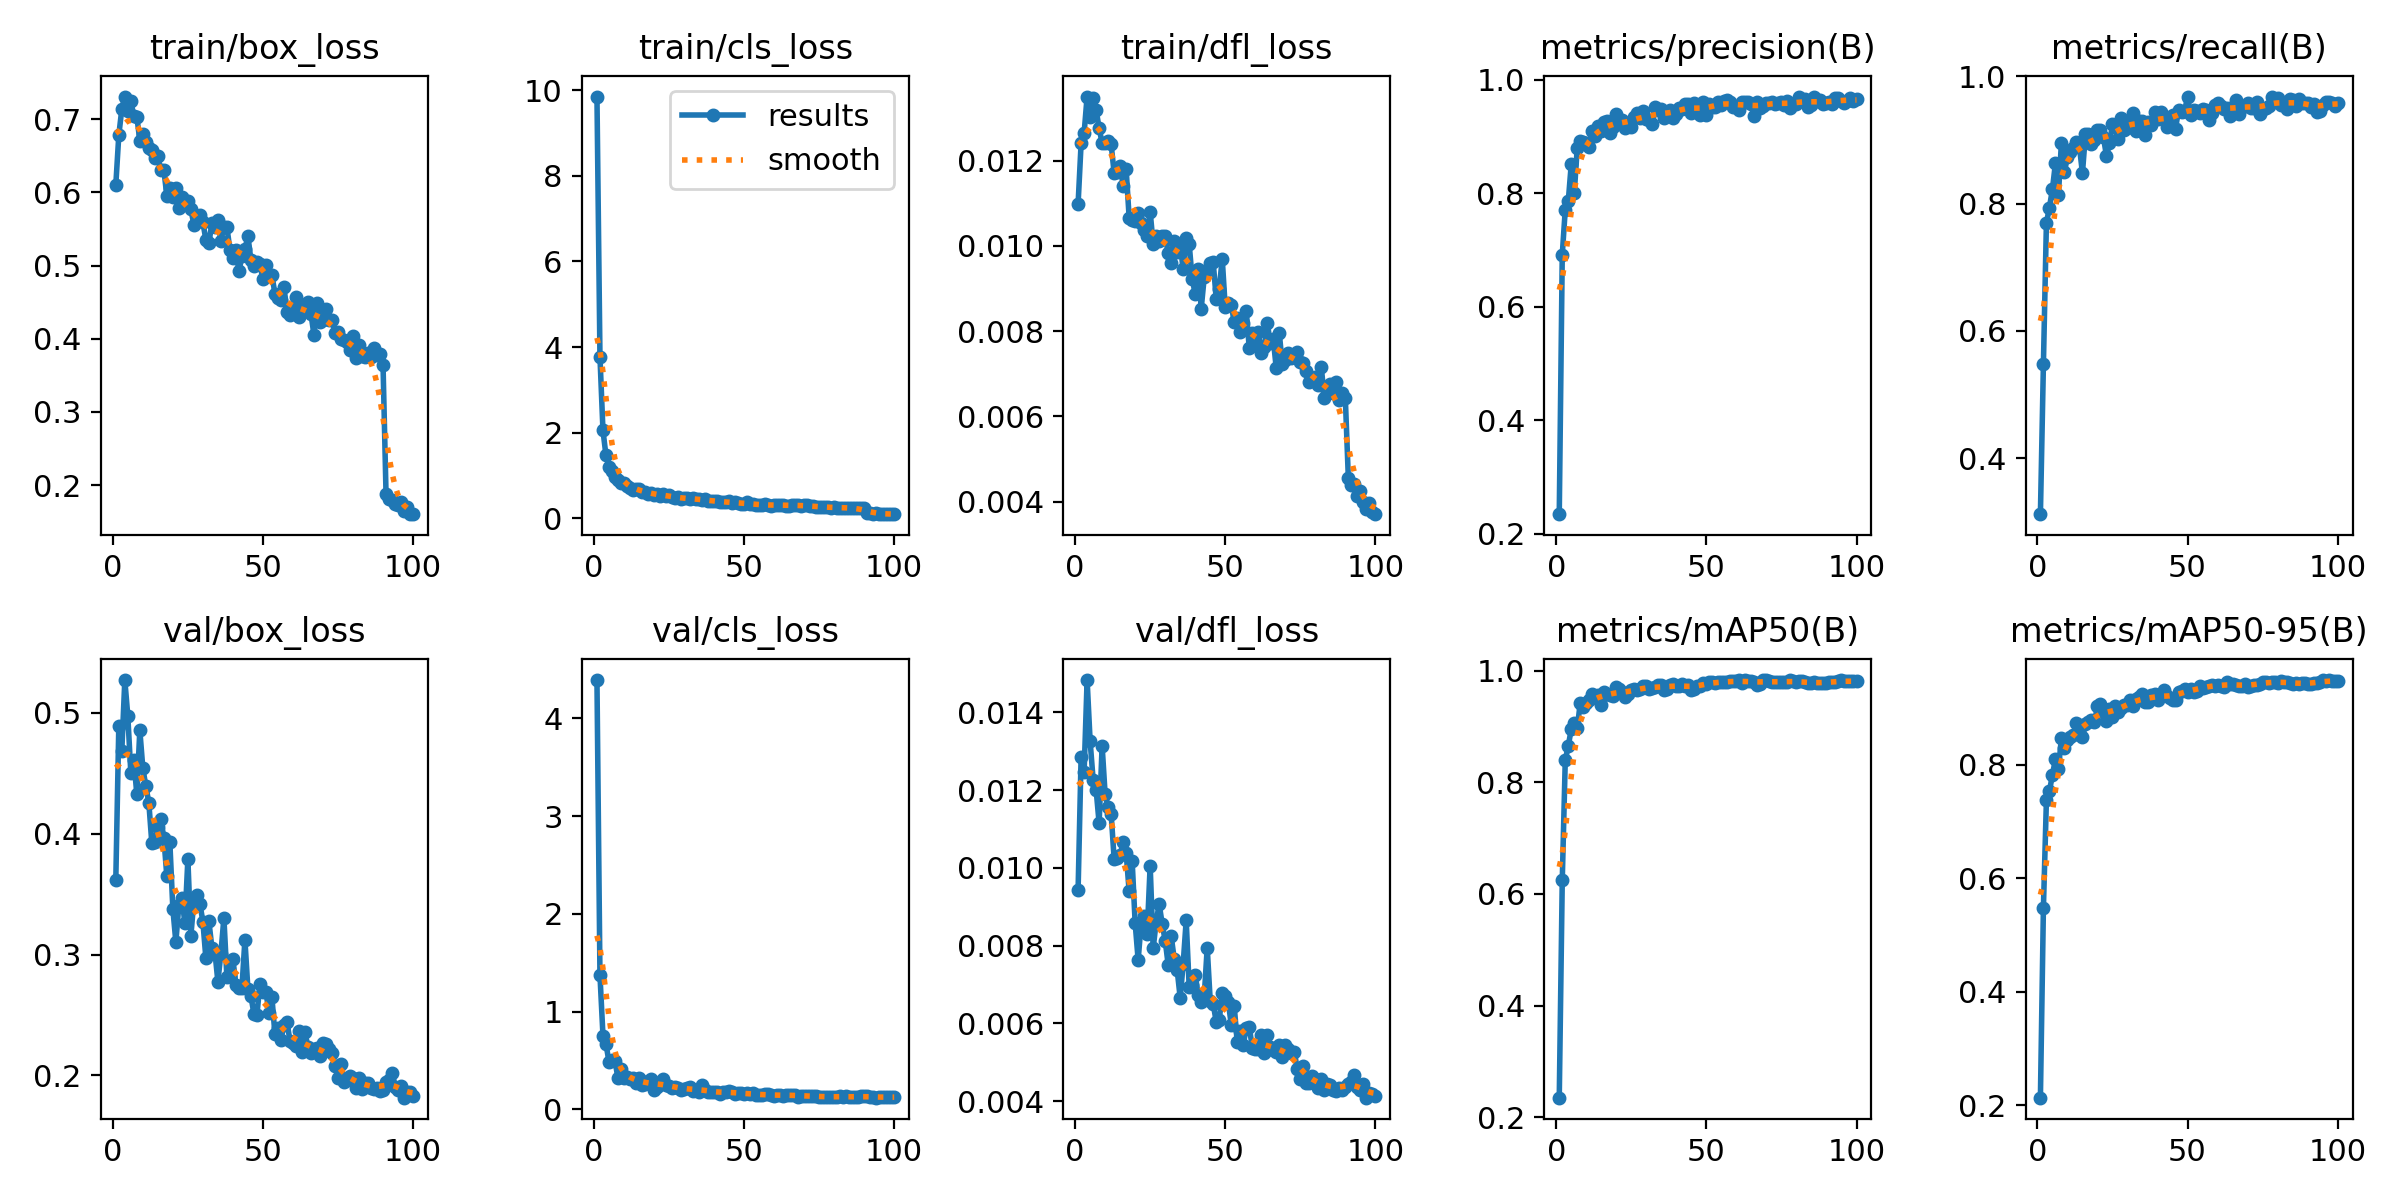

In [ ]:
import os
from IPython.display import Image, display

# 1. Find the latest train folder (Ultralytics auto-increments these)
# If this was your first run, it's 'runs/detect/train'
results_path = '/content/drive/MyDrive/YOLO26_WasteProject/waste_run_1/results.png'

# 2. Display the image
if os.path.exists(results_path):
    display(Image(filename=results_path, width=1000))
else:
    print("Results image not found yet. Make sure training has started!")

### Curious? Visualize Our Training Data with Labels

After training starts, view `train*.jpg` images to see training images, labels and augmentation effects.

Note a mosaic dataloader is used for training (shown below), a new dataloading concept developed by Glenn Jocher and first featured in [YOLOv4](https://arxiv.org/abs/2004.10934).

GROUND TRUTH TRAINING DATA:


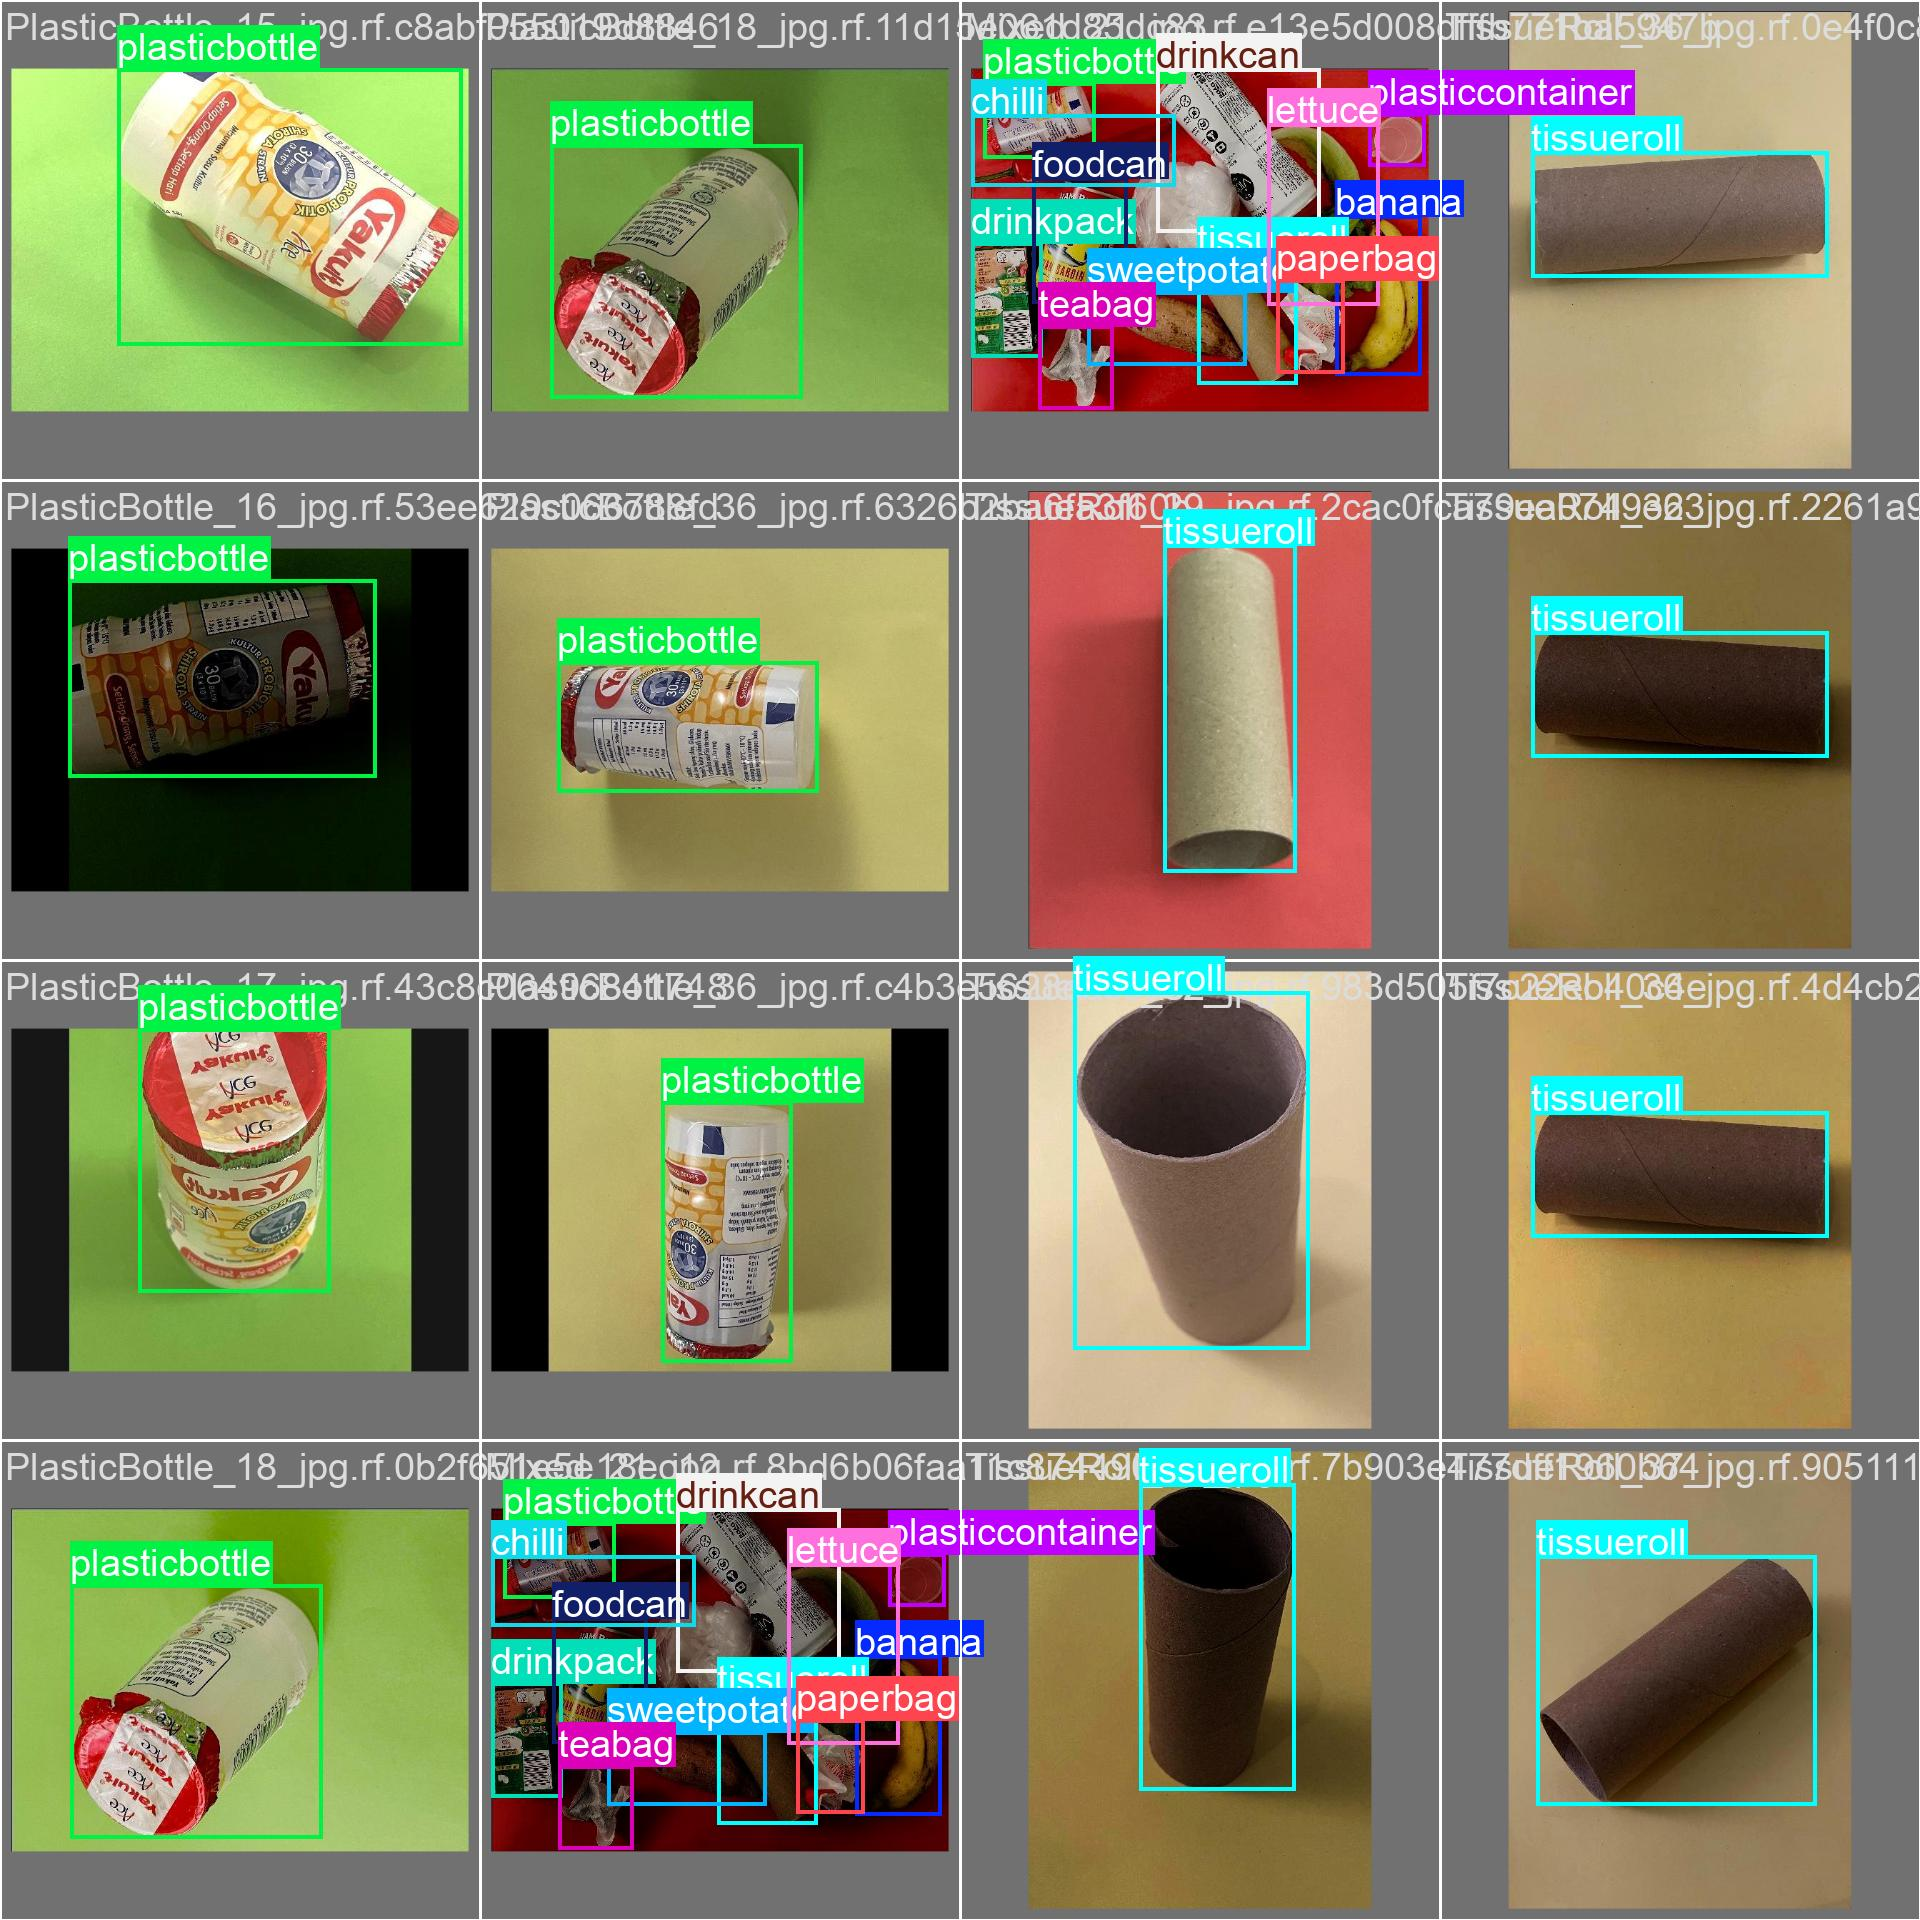

In [ ]:
# first, display our ground truth data
print("GROUND TRUTH TRAINING DATA:")
Image(filename='/content/drive/MyDrive/YOLO26_WasteProject/waste_run_1/val_batch0_labels.jpg', width=900)

GROUND TRUTH AUGMENTED TRAINING DATA:


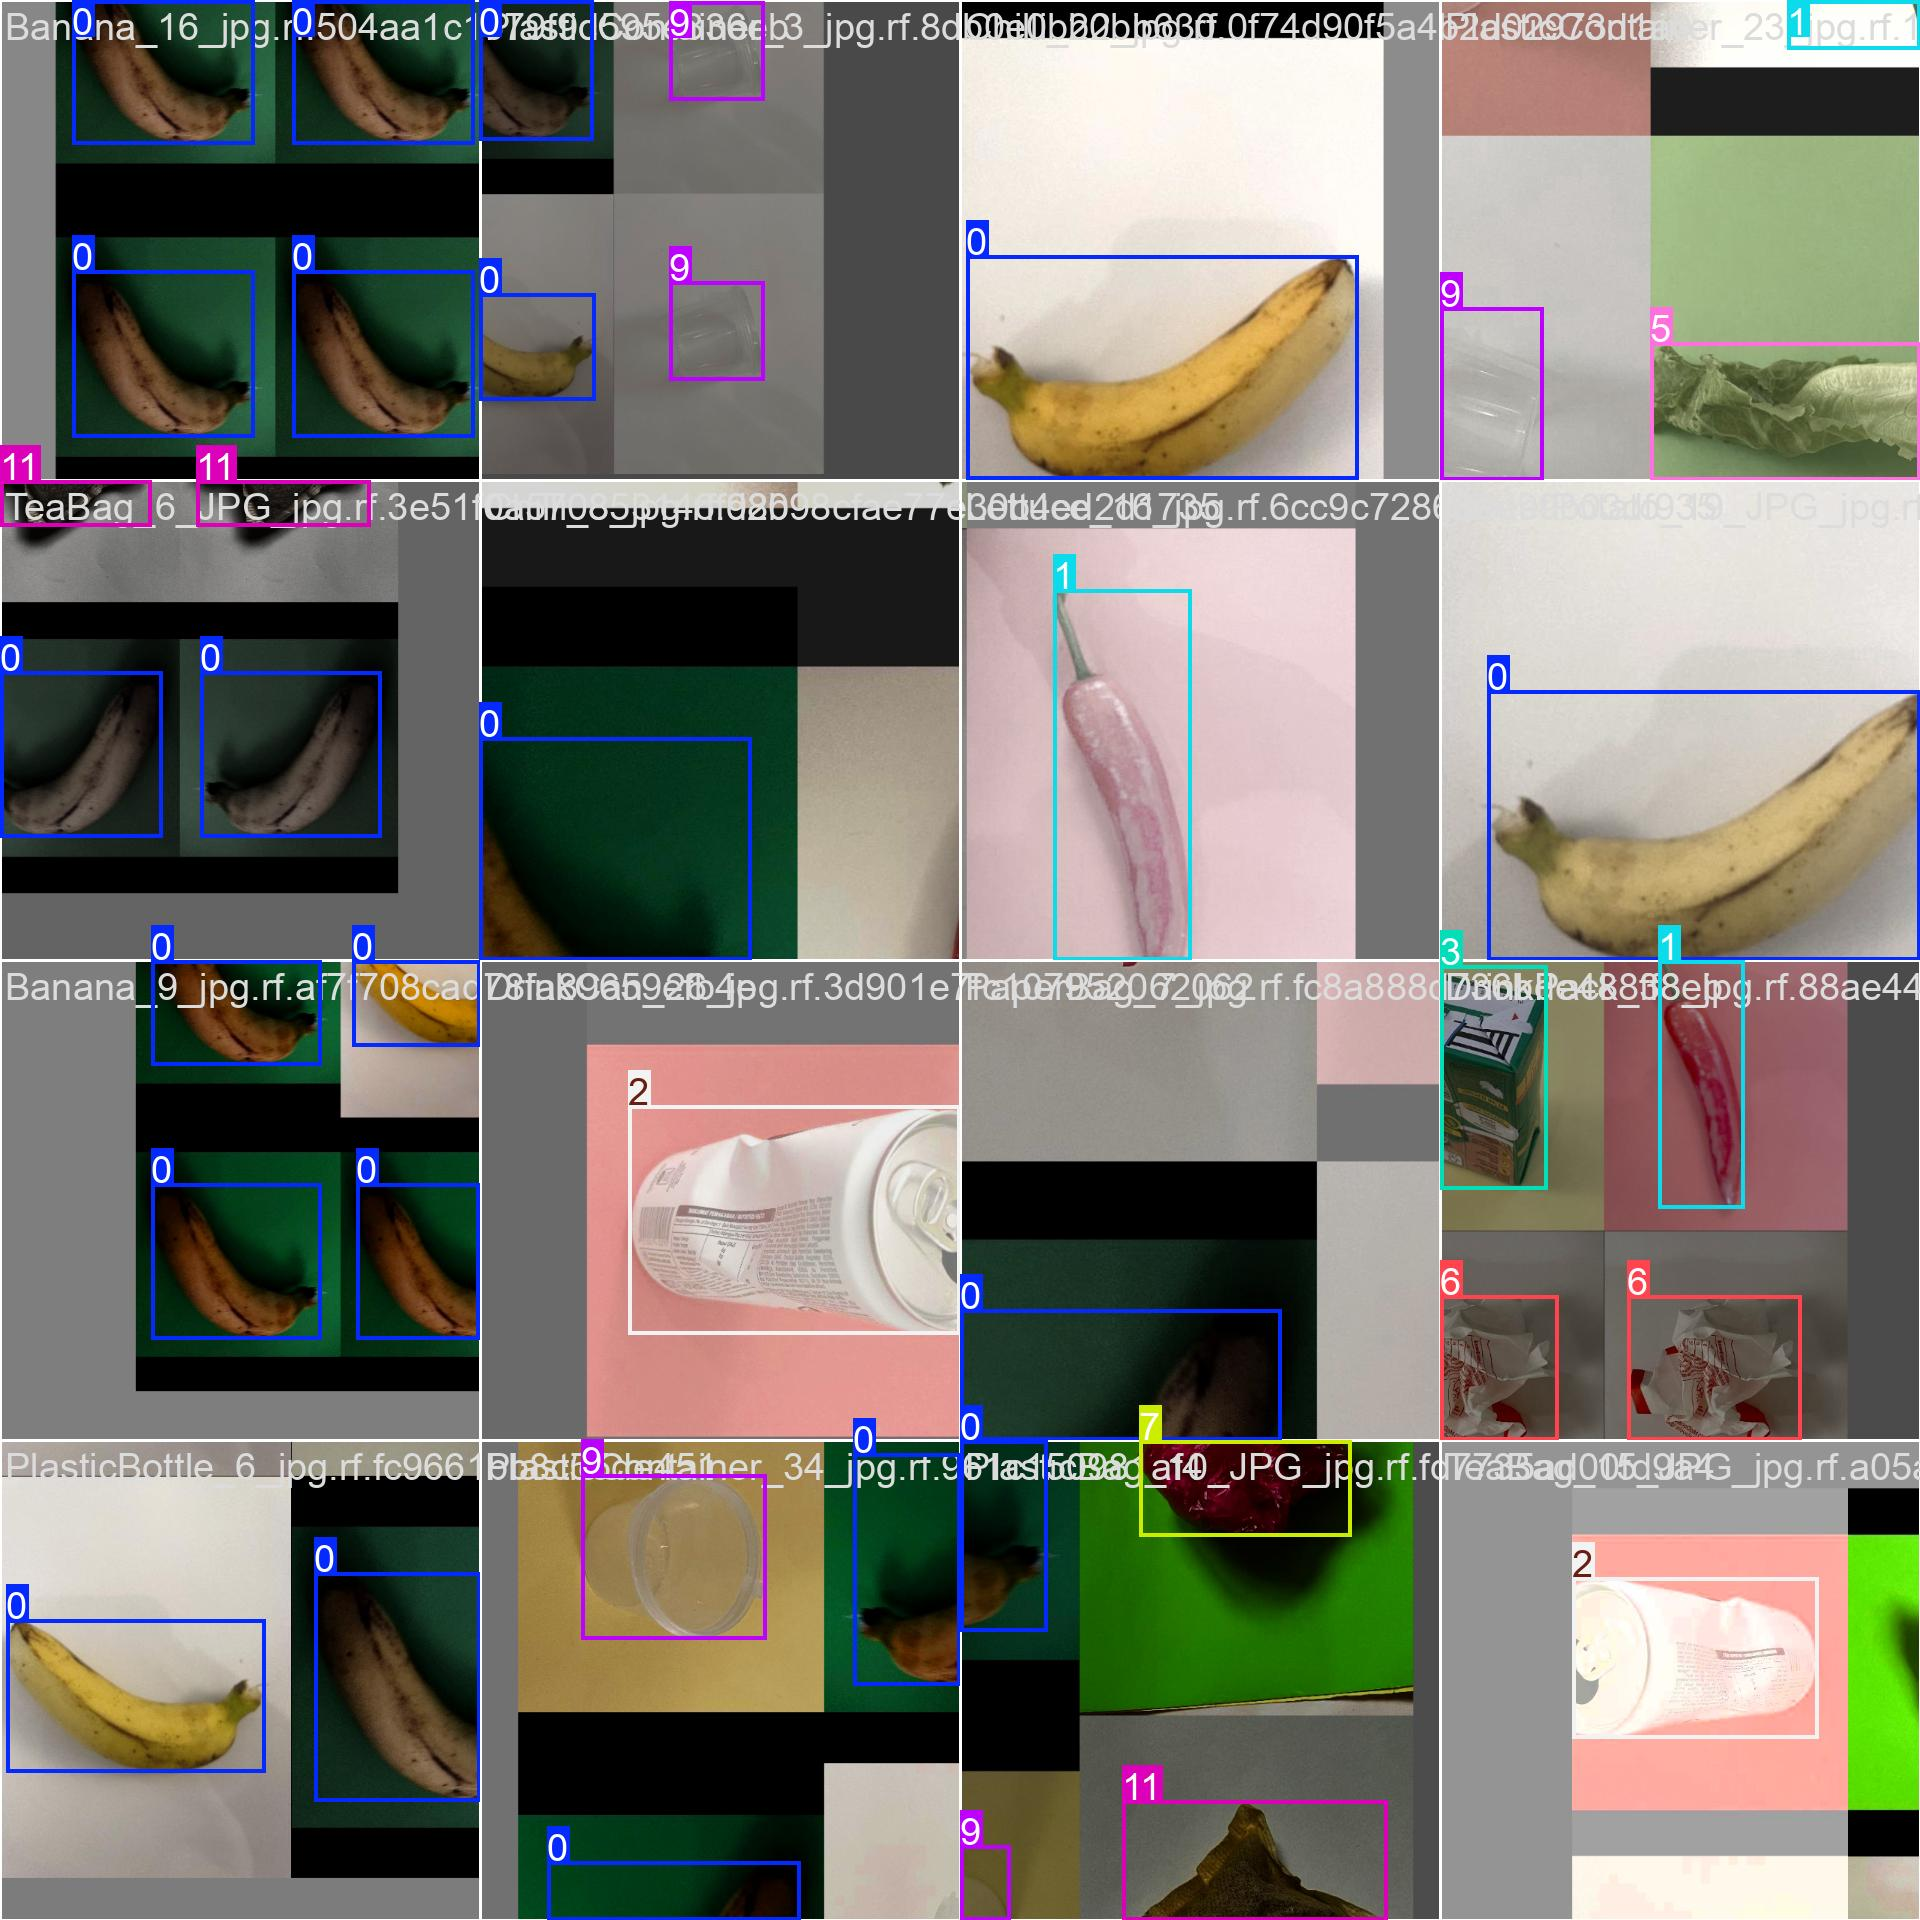

In [ ]:
# print out an augmented training example
print("GROUND TRUTH AUGMENTED TRAINING DATA:")
Image(filename='/content/drive/MyDrive/YOLO26_WasteProject/waste_run_1/train_batch0.jpg', width=900)

#Run Inference  With Trained Weights
Run inference with a pretrained checkpoint on contents of `test/images` folder downloaded from Roboflow.

In [ ]:
# trained weights are saved by default in our weights folder
%ls runs/

train/


In [ ]:
%ls runs/train/yolov5s_results/weights

best.pt  last.pt


In [ ]:
from ultralytics import YOLO

# 1. Load your best trained weights
# Double check this path! If you are on Windows, ensure the slashes are correct.
model = YOLO("/content/drive/MyDrive/YOLO26_WasteProject/waste_run_1/weights/best.pt")

# 2. Run the prediction
results = model.predict(source="/content/valid/images", imgsz=416, conf=0.5, save=True)

print("Detection finished. Results saved to '/content/drive/MyDrive/YOLO26_WasteProject/waste_run_1/weights'")


image 1/459 /content/valid/images/Banana_10_jpg.rf.0f4f5f5b749f5681048000d59b667d94.jpg: 416x320 1 banana, 1263.5ms
image 2/459 /content/valid/images/Banana_10_jpg.rf.5d587c81371bd16a3a5eba3af30ce089.jpg: 416x320 1 banana, 233.9ms
image 3/459 /content/valid/images/Banana_11_jpg.rf.4db17dd527857ce32b0a5b4e932a8edd.jpg: 416x320 1 banana, 408.4ms
image 4/459 /content/valid/images/Banana_11_jpg.rf.725ac11c3b9a57b557aa002424b642b3.jpg: 416x320 1 banana, 355.8ms
image 5/459 /content/valid/images/Banana_11_jpg.rf.89eb370e96a2f40795c79bf99b0209ee.jpg: 416x320 1 banana, 523.1ms
image 6/459 /content/valid/images/Banana_12_jpg.rf.8062cfdd1da4ce783be45f308e9eb843.jpg: 416x320 1 banana, 352.4ms
image 7/459 /content/valid/images/Banana_14_jpg.rf.2b1dcca091892073ea5771141ffed640.jpg: 416x320 1 banana, 170.7ms
image 8/459 /content/valid/images/Banana_15_jpg.rf.7be650fb4778a0268070d15da2a2adab.jpg: 416x320 1 banana, 174.7ms
image 9/459 /content/valid/images/Banana_16_jpg.rf.1762a14a97f2165132a85b0fc3e